In [1]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
from shapely.geometry import LineString

# -----------------------------
# configuración general
# -----------------------------
CRS_PROJ = "EPSG:32719"
UMBRAL_CAMINATA_M = 1200
WALK_SPEED_M_MIN = 75
K_DESTINOS = 8
SEED = 42

np.random.seed(SEED)

In [2]:
FP_MANZ = Path("../data/processed/censo/manzanas_penalolen_sim.parquet")
FP_RED = Path("../data/raw/red_peatonal_penalolen.graphml")

FP_SALUD = Path("../data/raw/establecimientos_salud_penalolen.gpkg")
FP_COMERCIO = Path("../data/raw/comercio_penalolen.gpkg")
FP_VERDES = Path("../data/processed/destinations/verdes_points.gpkg")

In [3]:
print("Cargando red peatonal...")
G = ox.load_graphml(FP_RED)
G = ox.project_graph(G, to_crs=CRS_PROJ)

print("Cargando manzanas...")
manz = gpd.read_parquet(FP_MANZ).to_crs(CRS_PROJ)

print("Cargando destinos...")
salud = gpd.read_file(FP_SALUD).to_crs(CRS_PROJ)
comercio = gpd.read_file(FP_COMERCIO).to_crs(CRS_PROJ)
verdes = gpd.read_file(FP_VERDES).to_crs(CRS_PROJ)

print("manz:", manz.shape)
print("salud:", salud.shape)
print("comercio:", comercio.shape)
print("verdes:", verdes.shape)

Cargando red peatonal...
Cargando manzanas...
Cargando destinos...
manz: (1629, 14)
salud: (28, 41)
comercio: (173, 37)
verdes: (525, 3)


In [4]:
manz["n_agents"] = np.where(
    manz["n_edad_60_mas"] > 0,
    np.maximum(1, np.round(manz["n_edad_60_mas"] / 10).astype(int)),
    0
)

print(manz[["n_edad_60_mas", "n_agents"]].describe())
print("Total agentes a simular:", manz["n_agents"].sum())

rows = []

for _, row in manz.iterrows():
    n = int(row["n_agents"])
    if n <= 0:
        continue

    for _ in range(n):
        rows.append({
            "MANZENT": row["MANZENT"],
            "COD_MANZANA": row["COD_MANZANA"],
            "vuln_group": row["vuln_group"],
            "indice_vulnerabilidad": row["indice_vulnerabilidad"],
            "ndvi_mean": row["ndvi_mean"],
            "ndvi_norm": row["ndvi_norm"],
            "x_rep": row["x_rep"],
            "y_rep": row["y_rep"]
        })

agents = pd.DataFrame(rows)
agents["agent_id"] = range(1, len(agents) + 1)

print("Dimensión agentes:", agents.shape)
agents.head()

       n_edad_60_mas     n_agents
count    1629.000000  1629.000000
mean       27.457336     2.796194
std        29.195460     2.879686
min         0.000000     0.000000
25%        13.000000     1.000000
50%        21.000000     2.000000
75%        31.000000     3.000000
max       345.000000    34.000000
Total agentes a simular: 4555
Dimensión agentes: (4555, 9)


,MANZENT,COD_MANZANA,vuln_group,indice_vulnerabilidad,ndvi_mean,ndvi_norm,x_rep,y_rep,agent_id
0,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,1
1,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,2
2,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,3
3,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,4
4,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,5


In [5]:
agents["geometry"] = gpd.points_from_xy(
    agents["x_rep"],
    agents["y_rep"],
    crs=CRS_PROJ
)

agents = gpd.GeoDataFrame(
    agents,
    geometry="geometry",
    crs=CRS_PROJ
)

print(type(agents))
print(agents.crs)
agents.head()

<class 'geopandas.geodataframe.GeoDataFrame'>
EPSG:32719


,MANZENT,COD_MANZANA,vuln_group,indice_vulnerabilidad,ndvi_mean,ndvi_norm,x_rep,y_rep,agent_id,geometry
0,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,1,POINT (354095.616 6296588.567)
1,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,2,POINT (354095.616 6296588.567)
2,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,3,POINT (354095.616 6296588.567)
3,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,4,POINT (354095.616 6296588.567)
4,1.312201e+13,3,media,-0.129681,0.193705,0.329695,354095.616422,6.296589e+06,5,POINT (354095.616 6296588.567)


In [6]:
def standardize_destinations(gdf, dest_type, id_prefix):
    out = gdf.copy()

    if not out.geom_type.eq("Point").all():
        out["geometry"] = out.representative_point()

    out = out.reset_index(drop=True)
    out["dest_id"] = [f"{id_prefix}_{i}" for i in range(len(out))]
    out["dest_type"] = dest_type

    return out[["dest_id", "dest_type", "geometry"]].copy()

dest_salud = standardize_destinations(salud, "salud", "salud")
dest_comercio = standardize_destinations(comercio, "comercio", "com")
dest_verdes = standardize_destinations(verdes, "areas_verdes", "verde")

destinos = pd.concat(
    [dest_salud, dest_comercio, dest_verdes],
    ignore_index=True
)

destinos = gpd.GeoDataFrame(destinos, geometry="geometry", crs=CRS_PROJ)

print(destinos["dest_type"].value_counts())
destinos.head()

dest_type
areas_verdes    525
comercio        173
salud            28
Name: count, dtype: int64


,dest_id,dest_type,geometry
0,salud_0,salud,POINT (353434.200 6291266.143)
1,salud_1,salud,POINT (353792.507 6291753.605)
2,salud_2,salud,POINT (353291.018 6292017.275)
3,salud_3,salud,POINT (353306.732 6292059.327)
4,salud_4,salud,POINT (353577.132 6293478.774)


In [7]:
print("Asignando nodo a destinos...")
destinos["dest_node"] = destinos.geometry.apply(
    lambda p: ox.distance.nearest_nodes(G, p.x, p.y)
)

print("Asignando nodo origen a agentes...")
agents["origin_node"] = agents.geometry.apply(
    lambda p: ox.distance.nearest_nodes(G, p.x, p.y)
)

agents[["agent_id", "origin_node"]].head()

Asignando nodo a destinos...


C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\geopandas\geoseries.py:645: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  result = super().apply(func, convert_dtype=convert_dtype, args=args, **kwargs)


Asignando nodo origen a agentes...


C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\geopandas\geoseries.py:645: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  result = super().apply(func, convert_dtype=convert_dtype, args=args, **kwargs)


,agent_id,origin_node
0,1,11071992926
1,2,11071992926
2,3,11071992926
3,4,11071992926
4,5,11071992926


In [8]:
def assign_destination(agent_geom, destinos_gdf, k=8):
    cand = destinos_gdf.copy()

    cand["euclid_dist"] = cand.geometry.distance(agent_geom)
    cand = cand.sort_values("euclid_dist").head(k).copy()

    if cand.empty:
        return pd.Series({
            "dest_id": None,
            "dest_type": None,
            "dest_node": None,
            "euclid_dist_m": np.nan
        })

    cand["w"] = 1 / (cand["euclid_dist"] + 1)
    probs = cand["w"] / cand["w"].sum()

    chosen_idx = np.random.choice(cand.index, p=probs.values)
    chosen = cand.loc[chosen_idx]

    return pd.Series({
        "dest_id": chosen["dest_id"],
        "dest_type": chosen["dest_type"],
        "dest_node": chosen["dest_node"],
        "euclid_dist_m": chosen["euclid_dist"]
    })

In [9]:
agents[["dest_id", "dest_type", "dest_node", "euclid_dist_m"]] = agents.apply(
    lambda row: assign_destination(
        agent_geom=row["geometry"],
        destinos_gdf=destinos,
        k=K_DESTINOS
    ),
    axis=1
)

print(agents.shape)
agents[["agent_id", "dest_id", "dest_type", "dest_node", "euclid_dist_m"]].head()

(4555, 15)


,agent_id,dest_id,dest_type,dest_node,euclid_dist_m
0,1,salud_18,salud,11071992926,27.784801
1,2,com_104,comercio,206411284,424.076945
2,3,com_137,comercio,6013907749,314.139072
3,4,salud_18,salud,11071992926,27.784801
4,5,salud_18,salud,11071992926,27.784801


In [10]:
def vulnerability_factor(vg):
    if vg == "alta":
        return 1.25
    elif vg == "media":
        return 1.10
    return 1.0

In [11]:
def classify_risk(heat_load):
    if heat_load >= 1200:
        return "alto"
    elif heat_load >= 700:
        return "medio"
    return "bajo"

In [12]:
def route_to_linestring(route, graph):
    coords = [(graph.nodes[n]["x"], graph.nodes[n]["y"]) for n in route]
    return LineString(coords)

In [13]:
def compute_route_ndvi(route_geom, manz):
    if route_geom is None:
        return np.nan

    if route_geom.geom_type == "Point":
        inter = manz[manz.contains(route_geom)].copy()

        if inter.empty:
            inter = manz[manz.intersects(route_geom)].copy()

        if inter.empty:
            return np.nan

        return inter["ndvi_mean"].mean()

    inter = manz[manz.intersects(route_geom)].copy()

    if inter.empty:
        return np.nan

    inter["geom_int"] = inter.geometry.intersection(route_geom)
    inter["len_int"] = inter["geom_int"].length

    total_len = inter["len_int"].sum()

    if total_len == 0:
        return np.nan

    ndvi_route = (inter["len_int"] * inter["ndvi_mean"]).sum() / total_len
    return ndvi_route

In [14]:
def simulate_trip(agent_row, graph, manz, walk_speed_m_min=75):
    origin = agent_row["origin_node"]
    dest = agent_row["dest_node"]

    if pd.isna(dest):
        return {
            "route": None,
            "route_length_m": np.nan,
            "travel_time_min_model": np.nan,
            "heat_load": np.nan,
            "risk_level": "error",
            "ndvi_route": np.nan
        }

    try:
        route = nx.shortest_path(graph, origin, dest, weight="length")
    except Exception:
        return {
            "route": None,
            "route_length_m": np.nan,
            "travel_time_min_model": np.nan,
            "heat_load": np.nan,
            "risk_level": "error",
            "ndvi_route": np.nan
        }

    if len(route) == 1:
        return {
            "route": route,
            "route_length_m": 0.0,
            "travel_time_min_model": 0.0,
            "heat_load": 0.0,
            "risk_level": "bajo",
            "ndvi_route": agent_row["ndvi_mean"]
        }

    route_length_m = nx.path_weight(graph, route, weight="length")
    travel_time_min_model = route_length_m / walk_speed_m_min

    route_geom = route_to_linestring(route, graph)

    ndvi_route = compute_route_ndvi(route_geom, manz)
    if np.isnan(ndvi_route):
        ndvi_route = agent_row["ndvi_mean"]

    vf = vulnerability_factor(agent_row["vuln_group"])

    ndvi_norm = (ndvi_route - manz["ndvi_mean"].min()) / (
        manz["ndvi_mean"].max() - manz["ndvi_mean"].min()
    )
    ndvi_norm = np.clip(ndvi_norm, 0, 1)

    base_rate = 1.0
    cooling_strength = 0.8
    effective_rate = max(0.2, base_rate - cooling_strength * ndvi_norm)

    heat_load = route_length_m * vf * effective_rate
    risk_level = classify_risk(heat_load)

    return {
        "route": route,
        "route_length_m": route_length_m,
        "travel_time_min_model": travel_time_min_model,
        "heat_load": heat_load,
        "risk_level": risk_level,
        "ndvi_route": ndvi_route
    }

In [15]:
results = []

for _, row in agents.iterrows():
    sim = simulate_trip(row, G, manz, walk_speed_m_min=WALK_SPEED_M_MIN)

    results.append({
        "agent_id": row["agent_id"],
        "MANZENT": row["MANZENT"],
        "COD_MANZANA": row["COD_MANZANA"],
        "vuln_group": row["vuln_group"],
        "indice_vulnerabilidad": row["indice_vulnerabilidad"],
        "ndvi_mean": row["ndvi_mean"],
        "ndvi_norm": row["ndvi_norm"],
        "origin_node": row["origin_node"],
        "dest_id": row["dest_id"],
        "dest_type": row["dest_type"],
        "dest_node": row["dest_node"],
        "euclid_dist_m": row["euclid_dist_m"],
        "route": sim["route"],
        "route_length_m": sim["route_length_m"],
        "travel_time_min_model": sim["travel_time_min_model"],
        "heat_load": sim["heat_load"],
        "risk_level": sim["risk_level"],
        "ndvi_route": sim["ndvi_route"]
    })

results_all = pd.DataFrame(results)

print(results_all.shape)
results_all.head()

(4555, 18)


,agent_id,MANZENT,COD_MANZANA,vuln_group,indice_vulnerabilidad,ndvi_mean,ndvi_norm,origin_node,dest_id,dest_type,dest_node,euclid_dist_m,route,route_length_m,travel_time_min_model,heat_load,risk_level,ndvi_route
0,1,1.312201e+13,3,media,-0.129681,0.193705,0.329695,11071992926,salud_18,salud,11071992926,27.784801,[11071992926],0.000,0.000000,0.000000,bajo,0.193705
1,2,1.312201e+13,3,media,-0.129681,0.193705,0.329695,11071992926,com_104,comercio,206411284,424.076945,"[11071992926, 11071956893, 4114504917, 6013928...",593.248,7.909973,480.452762,bajo,0.193705
2,3,1.312201e+13,3,media,-0.129681,0.193705,0.329695,11071992926,com_137,comercio,6013907749,314.139072,"[11071992926, 11071956893, 2344920544, 5414311...",577.803,7.704040,467.944346,bajo,0.193705
3,4,1.312201e+13,3,media,-0.129681,0.193705,0.329695,11071992926,salud_18,salud,11071992926,27.784801,[11071992926],0.000,0.000000,0.000000,bajo,0.193705
4,5,1.312201e+13,3,media,-0.129681,0.193705,0.329695,11071992926,salud_18,salud,11071992926,27.784801,[11071992926],0.000,0.000000,0.000000,bajo,0.193705


In [16]:
results_walk = results_all[
    results_all["route_length_m"] <= UMBRAL_CAMINATA_M
].copy()

print("Viajes totales:", results_all.shape[0])
print("Viajes plausibles a pie:", results_walk.shape[0])
print("Proporción retenida:", results_walk.shape[0] / max(results_all.shape[0], 1))

Viajes totales: 4555
Viajes plausibles a pie: 4418
Proporción retenida: 0.9699231613611417


In [17]:
resumen_vuln = (
    results_walk
    .groupby("vuln_group")
    .agg(
        n_agents=("agent_id", "count"),
        dist_mean_m=("route_length_m", "mean"),
        dist_median_m=("route_length_m", "median"),
        heat_mean=("heat_load", "mean"),
        heat_median=("heat_load", "median"),
        ndvi_route_mean=("ndvi_route", "mean")
    )
    .reset_index()
)

print(resumen_vuln)

  vuln_group  n_agents  dist_mean_m  dist_median_m   heat_mean  heat_median  \
0       alta      1489   255.899377       236.5920  266.434942   247.260012   
1       baja      1332   349.133954       276.9535  217.182510   181.401552   
2      media      1597   275.233081       243.1670  246.350454   220.328450   

   ndvi_route_mean  
0         0.128264  
1         0.267490  
2         0.139799  


In [18]:
resumen_dest = (
    results_walk
    .groupby("dest_type")
    .agg(
        n_agents=("agent_id", "count"),
        dist_mean_m=("route_length_m", "mean"),
        heat_mean=("heat_load", "mean"),
        ndvi_route_mean=("ndvi_route", "mean")
    )
    .reset_index()
)

print(resumen_dest)

      dest_type  n_agents  dist_mean_m   heat_mean  ndvi_route_mean
0  areas_verdes      3376   293.361706  243.306482         0.180610
1      comercio       875   281.528350  246.406804         0.154008
2         salud       167   292.822772  254.022570         0.155965


In [19]:
print(
    results_walk.groupby("vuln_group")["risk_level"]
    .value_counts(normalize=True)
)

vuln_group  risk_level
alta        bajo          0.975823
            medio         0.023506
            alto          0.000672
baja        bajo          0.986486
            medio         0.013514
media       bajo          0.979336
            medio         0.020664
Name: proportion, dtype: float64


In [20]:
risk_map = (
    results_walk
    .groupby("MANZENT")
    .agg(
        n_agents=("agent_id", "count"),
        heat_mean=("heat_load", "mean"),
        heat_max=("heat_load", "max"),
        dist_mean_m=("route_length_m", "mean"),
        dist_median_m=("route_length_m", "median"),
        pct_risk_high=("risk_level", lambda x: (x == "alto").mean()),
        pct_risk_medium=("risk_level", lambda x: (x == "medio").mean())
    )
    .reset_index()
)

manz_plot = manz.merge(risk_map, on="MANZENT", how="left")
manz_plot.head()

,MANZENT,COD_MANZANA,n_per,n_edad_60_mas,indice_vulnerabilidad,vuln_group,x_rep,y_rep,geometry,ndvi_mean,...,ndvi_norm,ndvi_q,n_agents_x,n_agents_y,heat_mean,heat_max,dist_mean_m,dist_median_m,pct_risk_high,pct_risk_medium
0,1.312201e+13,3,134.0,53.0,-0.129681,media,354095.616422,6.296589e+06,"MULTIPOLYGON (((354058.672 6296650.284, 353963...",0.193705,...,0.329695,Alto,5,5.0,189.679422,480.452762,234.210200,0.0000,0.0,0.0
1,1.312201e+13,6,118.0,27.0,-0.176136,media,354242.843965,6.296505e+06,"MULTIPOLYGON (((354200.259 6296552.088, 354212...",0.152711,...,0.254621,Medio,3,3.0,354.213153,453.571507,423.291000,376.0290,0.0,0.0
2,1.312201e+13,7,9.0,4.0,-0.376962,baja,353831.281093,6.296461e+06,"MULTIPOLYGON (((353840.343 6296401.973, 353841...",0.049209,...,0.065071,Muy bajo,1,1.0,150.840453,150.840453,159.124000,159.1240,0.0,0.0
3,1.312201e+13,8,47.0,10.0,0.215923,media,354400.351163,6.296437e+06,"MULTIPOLYGON (((354460.616 6296396.127, 354459...",0.200934,...,0.342935,Alto,1,1.0,133.797201,133.797201,167.620000,167.6200,0.0,0.0
4,1.312201e+13,9,240.0,63.0,-0.397915,baja,353977.039554,6.296382e+06,"MULTIPOLYGON (((354064.167 6296424.865, 354062...",0.242425,...,0.418921,Alto,6,6.0,327.301791,423.711514,462.313833,428.7115,0.0,0.0


In [21]:
print(
    manz_plot[["heat_mean", "ndvi_mean"]]
    .dropna()
    .corr()
)

           heat_mean  ndvi_mean
heat_mean   1.000000  -0.208985
ndvi_mean  -0.208985   1.000000


In [22]:
print(
    results_walk[["heat_load", "ndvi_route", "route_length_m"]]
    .dropna()
    .corr()
)

                heat_load  ndvi_route  route_length_m
heat_load        1.000000   -0.191111        0.906207
ndvi_route      -0.191111    1.000000        0.134677
route_length_m   0.906207    0.134677        1.000000


In [23]:
for umbral in [800, 1200, 1500]:
    tmp = results_all[results_all["route_length_m"] <= umbral].copy()

    print(f"\n--- Umbral = {umbral} m ---")
    print("n viajes:", tmp.shape[0])

    if tmp.shape[0] > 0:
        print(tmp.groupby("vuln_group")["heat_load"].mean())
        print(tmp["risk_level"].value_counts(normalize=True))


--- Umbral = 800 m ---
n viajes: 4223
vuln_group
alta     255.579065
baja     179.892955
media    230.836385
Name: heat_load, dtype: float64
risk_level
bajo     0.995027
medio    0.004973
Name: proportion, dtype: float64

--- Umbral = 1200 m ---
n viajes: 4418
vuln_group
alta     266.434942
baja     217.182510
media    246.350454
Name: heat_load, dtype: float64
risk_level
bajo     0.980308
medio    0.019466
alto     0.000226
Name: proportion, dtype: float64

--- Umbral = 1500 m ---
n viajes: 4483
vuln_group
alta     267.422582
baja     240.086359
media    248.310125
Name: heat_load, dtype: float64
risk_level
bajo     0.970555
medio    0.029222
alto     0.000223
Name: proportion, dtype: float64


In [24]:
for umbral in [800, 1200, 1500]:
    tmp = results_all[results_all["route_length_m"] <= umbral].copy()

    print(f"\n--- Umbral = {umbral} m ---")
    print("n viajes:", tmp.shape[0])

    if tmp.shape[0] > 0:
        print(tmp.groupby("vuln_group")["heat_load"].mean())
        print(tmp["risk_level"].value_counts(normalize=True))


--- Umbral = 800 m ---
n viajes: 4223
vuln_group
alta     255.579065
baja     179.892955
media    230.836385
Name: heat_load, dtype: float64
risk_level
bajo     0.995027
medio    0.004973
Name: proportion, dtype: float64

--- Umbral = 1200 m ---
n viajes: 4418
vuln_group
alta     266.434942
baja     217.182510
media    246.350454
Name: heat_load, dtype: float64
risk_level
bajo     0.980308
medio    0.019466
alto     0.000226
Name: proportion, dtype: float64

--- Umbral = 1500 m ---
n viajes: 4483
vuln_group
alta     267.422582
baja     240.086359
media    248.310125
Name: heat_load, dtype: float64
risk_level
bajo     0.970555
medio    0.029222
alto     0.000223
Name: proportion, dtype: float64


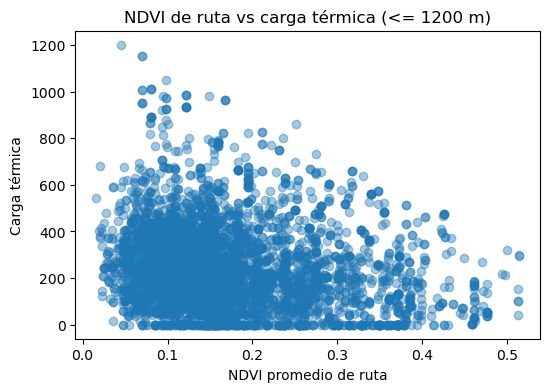

In [25]:
plt.figure(figsize=(6, 4))
plt.scatter(results_walk["ndvi_route"], results_walk["heat_load"], alpha=0.4)
plt.xlabel("NDVI promedio de ruta")
plt.ylabel("Carga térmica")
plt.title(f"NDVI de ruta vs carga térmica (<= {UMBRAL_CAMINATA_M} m)")
plt.show()

<Figure size 700x400 with 0 Axes>

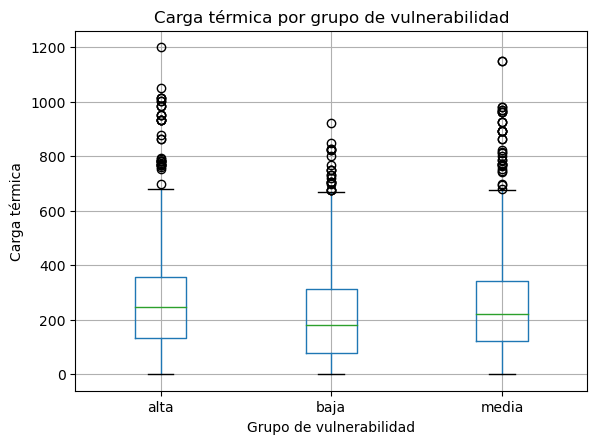

In [26]:
plt.figure(figsize=(7, 4))
results_walk.boxplot(column="heat_load", by="vuln_group")
plt.title("Carga térmica por grupo de vulnerabilidad")
plt.suptitle("")
plt.xlabel("Grupo de vulnerabilidad")
plt.ylabel("Carga térmica")
plt.show()

<Figure size 700x400 with 0 Axes>

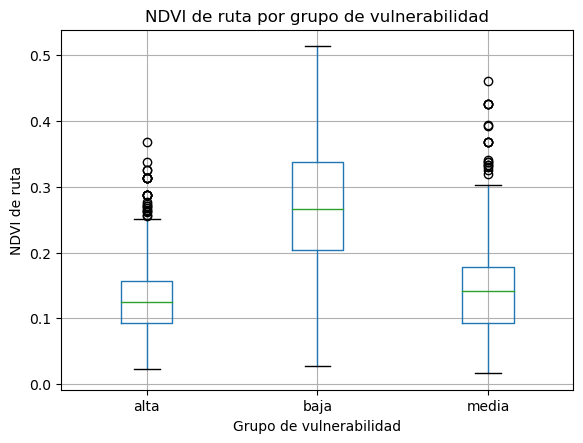

In [27]:
plt.figure(figsize=(7, 4))
results_walk.boxplot(column="ndvi_route", by="vuln_group")
plt.title("NDVI de ruta por grupo de vulnerabilidad")
plt.suptitle("")
plt.xlabel("Grupo de vulnerabilidad")
plt.ylabel("NDVI de ruta")
plt.show()

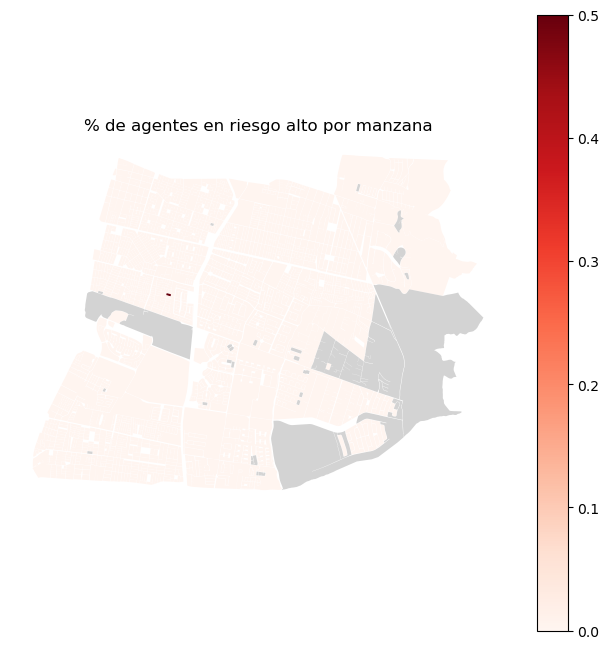

In [28]:
ax = manz_plot.plot(
    column="pct_risk_high",
    cmap="Reds",
    legend=True,
    figsize=(8, 8),
    missing_kwds={"color": "lightgrey", "label": "Sin agentes"}
)
ax.set_title("% de agentes en riesgo alto por manzana")
ax.set_axis_off()
plt.show()

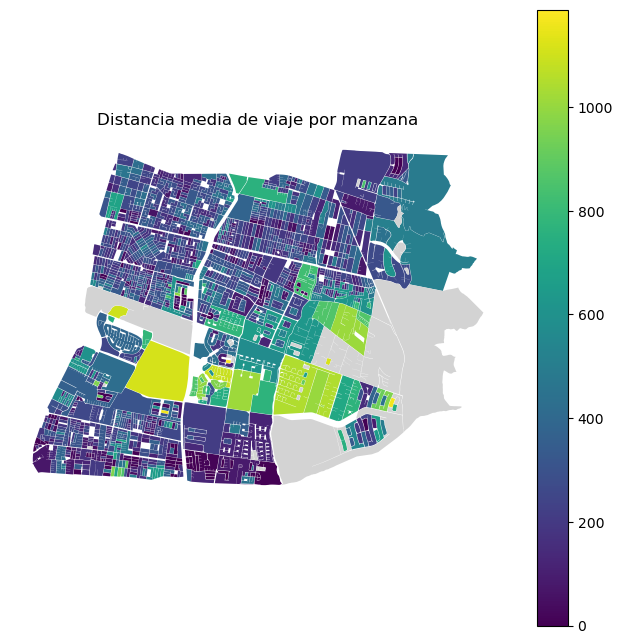

In [29]:
ax = manz_plot.plot(
    column="dist_mean_m",
    cmap="viridis",
    legend=True,
    figsize=(8, 8),
    missing_kwds={"color": "lightgrey", "label": "Sin agentes"}
)
ax.set_title("Distancia media de viaje por manzana")
ax.set_axis_off()
plt.show()

In [30]:
print(results_walk["dest_type"].value_counts())

dest_type
areas_verdes    3376
comercio         875
salud            167
Name: count, dtype: int64


In [31]:
print(
    results_walk.groupby("vuln_group")[["route_length_m", "heat_load", "ndvi_route"]]
    .mean()
)

            route_length_m   heat_load  ndvi_route
vuln_group                                        
alta            255.899377  266.434942    0.128264
baja            349.133954  217.182510    0.267490
media           275.233081  246.350454    0.139799


In [32]:
print(
    results_walk.groupby("dest_type")[["route_length_m", "heat_load", "ndvi_route"]]
    .mean()
)

              route_length_m   heat_load  ndvi_route
dest_type                                           
areas_verdes      293.361706  243.306482    0.180610
comercio          281.528350  246.406804    0.154008
salud             292.822772  254.022570    0.155965


In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

def plot_classified_map(
    gdf,
    column,
    title,
    category_order,
    colors,
    labels_en=None,
    background_gdf=None,
    figsize=(7, 7),
    edgecolor="#efefef",
    linewidth=0.001,
    missing_color="#f0f0f0",
    background_color="#eeeeee",
    background_edgecolor="#f7f7f7",
    background_linewidth=4
):
    gdf_plot = gdf.copy()

    gdf_plot[column] = pd.Categorical(
        gdf_plot[column],
        categories=category_order,
        ordered=True
    )

    color_map = dict(zip(category_order, colors))
    gdf_plot["_plot_color"] = gdf_plot[column].map(color_map).astype(object)
    gdf_plot["_plot_color"] = gdf_plot["_plot_color"].fillna(missing_color)

    fig, ax = plt.subplots(figsize=figsize)

    # fondo comunal/regional
    if background_gdf is not None:
        background_gdf.plot(
            ax=ax,
            color=background_color,
            edgecolor=background_edgecolor,
            linewidth=background_linewidth,
            zorder=1
        )

    # capa principal
    gdf_plot.plot(
        ax=ax,
        color=gdf_plot["_plot_color"],
        edgecolor=edgecolor,
        linewidth=linewidth,
        zorder=2
    )

    # mantener zoom a la capa principal
    xmin, ymin, xmax, ymax = gdf.total_bounds
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_title(title, fontsize=13, pad=10)
    ax.set_axis_off()
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")

    patches = [
        mpatches.Patch(color=color_map[cat], label=label_en)
        for cat, label_en in zip(category_order, labels_en)
    ]

    ax.legend(
        handles=patches,
        loc="upper left",
        frameon=True,
        facecolor="white",
        edgecolor="#d9d9d9",
        fontsize=9
    )

    plt.tight_layout()
    plt.show()

In [34]:
comunal = gpd.read_parquet("../data/raw/Cartografía_censo2024_R13_Comunal.parquet")
comunal = comunal.to_crs(manz.crs)

penalolen = comunal[comunal["COMUNA"].str.upper() == "PEÑALOLÉN"].copy()
penalolen = penalolen.to_crs(manz.crs)

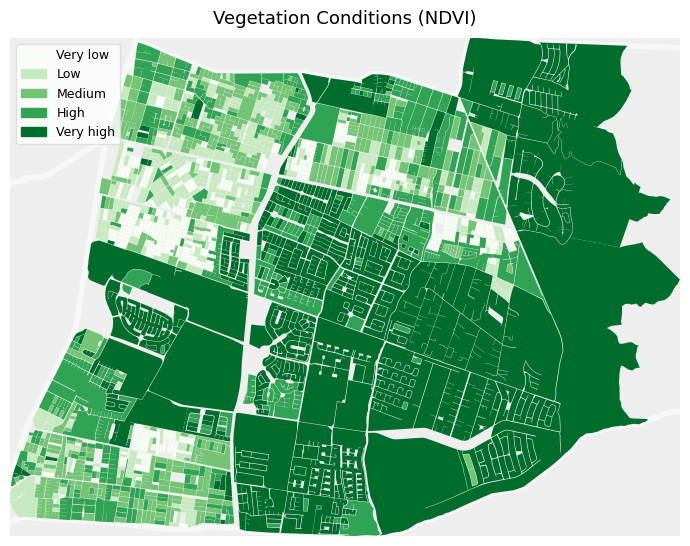

In [35]:
ndvi_order = ["Muy bajo", "Bajo", "Medio", "Alto", "Muy alto"]
ndvi_labels_en = ["Very low", "Low", "Medium", "High", "Very high"]
ndvi_colors = ["#f7fcf5", "#c7e9c0", "#74c476", "#31a354", "#006d2c"]

plot_classified_map(
    gdf=manz,
    column="ndvi_q",
    title="Vegetation Conditions (NDVI)",
    category_order=ndvi_order,
    colors=ndvi_colors,
    labels_en=ndvi_labels_en,
    background_gdf=comunal
)

In [36]:
manz["vuln_q"] = pd.qcut(
    manz["indice_vulnerabilidad"],
    q=5,
    labels=["Muy baja", "Baja", "Media", "Alta", "Muy alta"]
)

In [37]:
vuln_order = ["Muy baja", "Baja", "Media", "Alta", "Muy alta"]
vuln_labels_en = ["Very low", "Low", "Medium", "High", "Very high"]
vuln_colors = ["#fee5d9", "#fcbba1", "#fc9272", "#ef3b2c", "#99000d"]

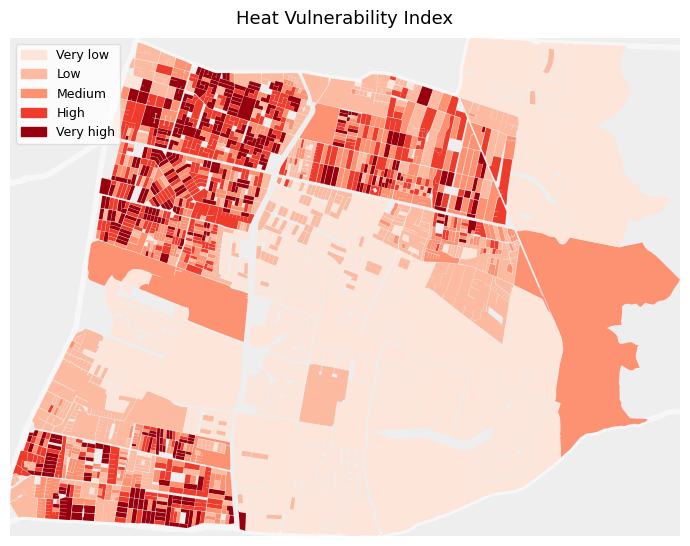

In [38]:
plot_classified_map(
    gdf=manz,
    column="vuln_q",
    title="Heat Vulnerability Index",
    category_order=vuln_order,
    colors=vuln_colors,
    labels_en=vuln_labels_en,
    background_gdf=comunal
)

In [39]:
def plot_classified_map_ax(
    gdf,
    column,
    ax,
    category_order,
    colors,
    labels_en,
    background_gdf=None,
    edgecolor="#f0f0f0",
    linewidth=0.10,
    background_color="#fcfcfc",
    background_edgecolor="#f2f2f2"
):
    gdf_plot = gdf.copy()

    gdf_plot[column] = pd.Categorical(
        gdf_plot[column],
        categories=category_order,
        ordered=True
    )

    color_map = dict(zip(category_order, colors))
    gdf_plot["_plot_color"] = gdf_plot[column].map(color_map).astype(object)

    # fondo
    if background_gdf is not None:
        background_gdf.plot(
            ax=ax,
            color=background_color,
            edgecolor=background_edgecolor,
            linewidth=0.3,
            zorder=1
        )

    # capa principal
    gdf_plot.plot(
        ax=ax,
        color=gdf_plot["_plot_color"],
        edgecolor=edgecolor,
        linewidth=linewidth,
        zorder=2
    )

    # borde comunal (si tienes penalolen)
    if "penalolen" in globals():
        penalolen.boundary.plot(
            ax=ax,
            color="#2b2b2b",
            linewidth=1.5,
            zorder=3
        )

    # zoom
    xmin, ymin, xmax, ymax = gdf.total_bounds
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_axis_off()

    # leyenda manual
    import matplotlib.patches as mpatches
    patches = [
        mpatches.Patch(color=color_map[c], label=l)
        for c, l in zip(category_order, labels_en)
    ]

    ax.legend(
        handles=patches,
        loc="upper left",
        frameon=True,
        facecolor="white",
        edgecolor="#d9d9d9",
        fontsize=8
    )

In [40]:
# NDVI
ndvi_order = ["Muy bajo", "Bajo", "Medio", "Alto", "Muy alto"]
ndvi_labels_en = ["Very low", "Low", "Medium", "High", "Very high"]
ndvi_colors = ["#f7fcf5", "#c7e9c0", "#74c476", "#31a354", "#006d2c"]

# Vulnerability
vuln_order = ["Muy baja", "Baja", "Media", "Alta", "Muy alta"]
vuln_labels_en = ["Very low", "Low", "Medium", "High", "Very high"]
vuln_colors = ["#fee5d9", "#fcbba1", "#fc9272", "#ef3b2c", "#99000d"]

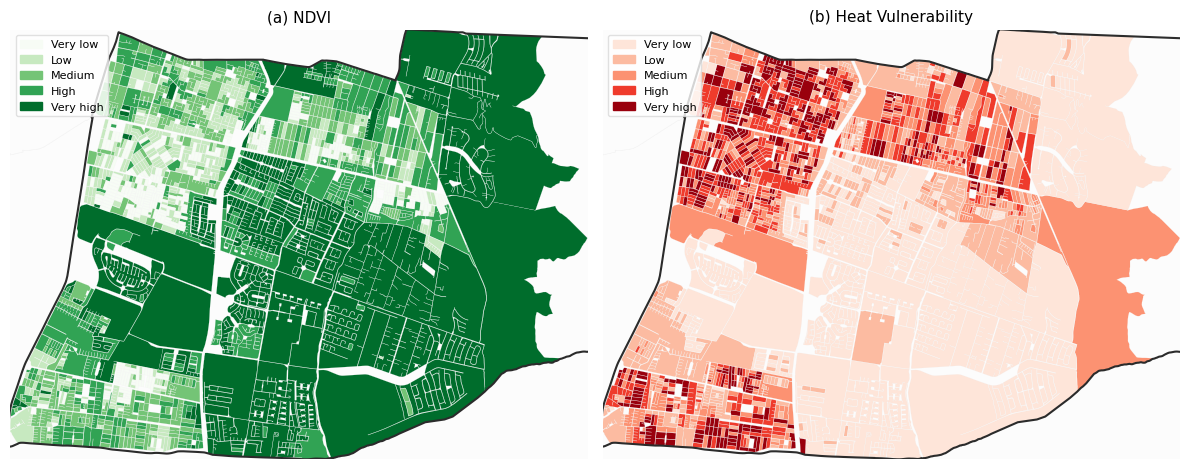

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# (a) NDVI
plot_classified_map_ax(
    gdf=manz,
    column="ndvi_q",
    ax=axes[0],
    category_order=ndvi_order,
    colors=ndvi_colors,
    labels_en=ndvi_labels_en,
    background_gdf=comunal
)
axes[0].set_title("(a) NDVI", fontsize=11)

# (b) Vulnerability
plot_classified_map_ax(
    gdf=manz,
    column="vuln_q",
    ax=axes[1],
    category_order=vuln_order,
    colors=vuln_colors,
    labels_en=vuln_labels_en,
    background_gdf=comunal
)
axes[1].set_title("(b) Heat Vulnerability", fontsize=11)

plt.tight_layout()
plt.show()

In [42]:
plt.savefig("fig1_ndvi_vulnerability.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

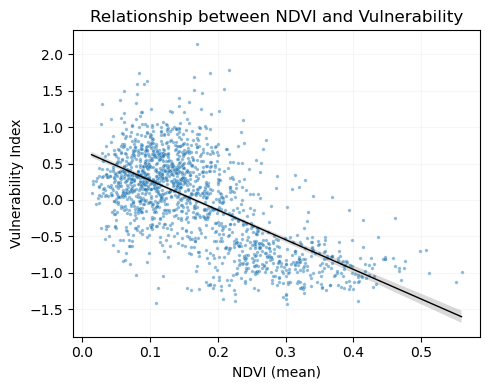

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

df = manz.copy()

plt.figure(figsize=(5, 4))

sns.scatterplot(
    data=df,
    x="ndvi_mean",
    y="indice_vulnerabilidad",
    alpha=0.5,
    s=6
)

sns.regplot(
    data=df,
    x="ndvi_mean",
    y="indice_vulnerabilidad",
    scatter=False,
    color="black",
    line_kws={"linewidth":1}
)

plt.xlabel("NDVI (mean)")
plt.ylabel("Vulnerability Index")
plt.title("Relationship between NDVI and Vulnerability")

plt.grid(alpha=0.1)

plt.tight_layout()
plt.show()

In [44]:
corr = df["ndvi_mean"].corr(df["indice_vulnerabilidad"])
print(f"Correlation NDVI vs Vulnerability: {corr:.3f}")

Correlation NDVI vs Vulnerability: -0.637


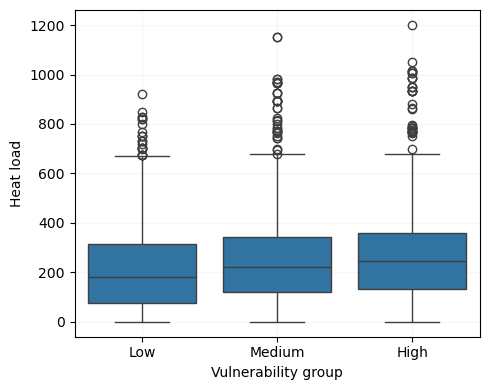

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.boxplot(
    data=results_walk,
    x="vuln_group",
    y="heat_load",
    order=["baja", "media", "alta"]
)

plt.xticks(
    ticks=[0,1,2],
    labels=["Low", "Medium", "High"]
)
plt.grid(alpha=0.1)
plt.xlabel("Vulnerability group")
plt.ylabel("Heat load")
plt.tight_layout()
plt.show()

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
# -----------------------------
# 1. exposición estática residencial
# -----------------------------
results_cmp = results_walk.copy()

# más vegetación = menor exposición
results_cmp["static_exposure"] = 1 - results_cmp["ndvi_norm"]

In [48]:
# -----------------------------
# 2. normalización 0-1 para comparar escalas
# -----------------------------
def minmax_norm(x):
    return (x - x.min()) / (x.max() - x.min())

results_cmp["static_exposure_norm"] = minmax_norm(results_cmp["static_exposure"])
results_cmp["dynamic_exposure_norm"] = minmax_norm(results_cmp["heat_load"])

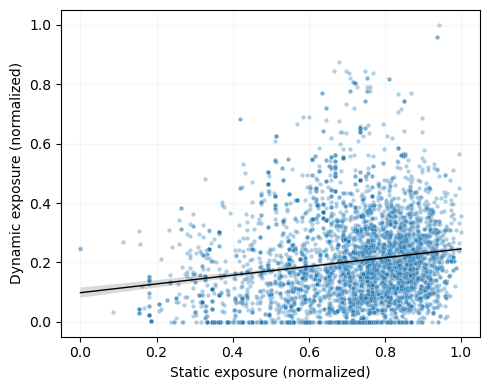

In [49]:
plt.figure(figsize=(5, 4))

sns.scatterplot(
    data=results_cmp,
    x="static_exposure_norm",
    y="dynamic_exposure_norm",
    alpha=0.35,
    s=10
)

sns.regplot(
    data=results_cmp,
    x="static_exposure_norm",
    y="dynamic_exposure_norm",
    scatter=False,
    color="black",
    line_kws={"linewidth": 1}
)

plt.xlabel("Static exposure (normalized)")
plt.ylabel("Dynamic exposure (normalized)")
plt.grid(alpha=0.1)
plt.tight_layout()
plt.show()

In [50]:
corr_sd = results_cmp["static_exposure_norm"].corr(results_cmp["dynamic_exposure_norm"])
print(f"Correlation static vs dynamic: {corr_sd:.3f}")

Correlation static vs dynamic: 0.165


In [51]:
cmp_block = (
    results_cmp
    .groupby("MANZENT")
    .agg(
        static_exp_mean=("static_exposure_norm", "mean"),
        dynamic_exp_mean=("dynamic_exposure_norm", "mean"),
        n_agents=("agent_id", "count")
    )
    .reset_index()
)

cmp_block["delta_exp"] = cmp_block["dynamic_exp_mean"] - cmp_block["static_exp_mean"]

cmp_block.head()

,MANZENT,static_exp_mean,dynamic_exp_mean,n_agents,delta_exp
0,1.312201e+13,0.670305,0.157965,5,-0.512340
1,1.312201e+13,0.745379,0.294989,3,-0.450390
2,1.312201e+13,0.934929,0.125620,1,-0.809308
3,1.312201e+13,0.657065,0.111426,1,-0.545639
4,1.312201e+13,0.581079,0.272577,6,-0.308502


In [52]:
manz_cmp = manz.merge(cmp_block, on="MANZENT", how="left")

In [53]:
manz_delta["delta_class"] = pd.cut(
    manz_delta["delta_exp_mean"],
    bins=[-1.0, -0.4, -0.3, -0.1, 1.0],
    labels=[
        "Much lower",
        "Lower",
        "Similar",
        "Higher"
    ]
)

NameError: name 'manz_delta' is not defined

In [ ]:
delta_order = ["Much lower", "Lower", "Similar", "Higher"]
delta_labels_en = ["Much lower", "Lower", "Similar", "Higher"]
delta_colors = ["#4575b4", "#91bfdb", "#f7f7f7", "#fc8d59"]

In [ ]:
plot_classified_map(
    gdf=manz_delta,
    column="delta_class",
    title="Difference between dynamic and static exposure",
    category_order=delta_order,
    colors=delta_colors,
    labels_en=delta_labels_en,
    background_gdf=comunal
)

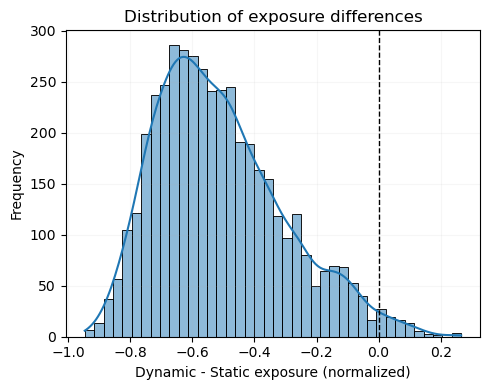

In [54]:
plt.figure(figsize=(5,4))

sns.histplot(
    results_cmp["dynamic_exposure_norm"] - results_cmp["static_exposure_norm"],
    bins=40,
    kde=True
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel("Dynamic - Static exposure (normalized)")
plt.ylabel("Frequency")
plt.title("Distribution of exposure differences")

plt.grid(alpha=0.1)
plt.tight_layout()
plt.show()

In [55]:
delta = results_cmp["dynamic_exposure_norm"] - results_cmp["static_exposure_norm"]

print("Mean delta:", delta.mean())
print("Median delta:", delta.median())
print("Std delta:", delta.std())

print("\nPercentiles:")
print(delta.quantile([0.05, 0.25, 0.5, 0.75, 0.95]))

Mean delta: -0.5102025335005507
Median delta: -0.5435323618889893
Std delta: 0.2073701576425735

Percentiles:
0.05   -0.794497
0.25   -0.664877
0.50   -0.543532
0.75   -0.384195
0.95   -0.109100
dtype: float64


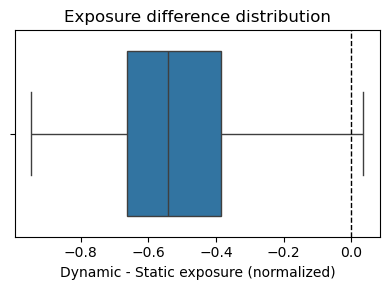

In [56]:
plt.figure(figsize=(4,3))

sns.boxplot(
    x=results_cmp["dynamic_exposure_norm"] - results_cmp["static_exposure_norm"],
    orient="h",
    showfliers=False
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel("Dynamic - Static exposure (normalized)")
plt.title("Exposure difference distribution")

plt.tight_layout()
plt.show()

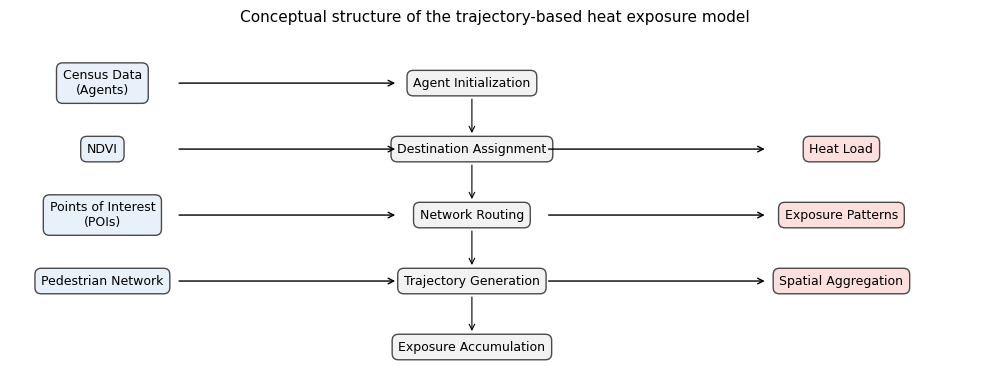

In [61]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

def draw_box(x, y, text, fc="#ffffff", ec="#4a4a4a"):
    ax.text(
        x, y, text,
        ha='center', va='center',
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.5", fc=fc, ec=ec, lw=1)
    )

# ===== INPUTS =====
draw_box(0, 2, "Census Data\n(Agents)", fc="#e8f1fa")
draw_box(0, 1, "NDVI", fc="#e8f1fa")
draw_box(0, 0, "Points of Interest\n(POIs)", fc="#e8f1fa")
draw_box(0, -1, "Pedestrian Network", fc="#e8f1fa")

# ===== MODEL =====
draw_box(4, 2, "Agent Initialization", fc="#f2f2f2")
draw_box(4, 1, "Destination Assignment", fc="#f2f2f2")
draw_box(4, 0, "Network Routing", fc="#f2f2f2")
draw_box(4, -1, "Trajectory Generation", fc="#f2f2f2")
draw_box(4, -2, "Exposure Accumulation", fc="#f2f2f2")

# ===== OUTPUTS =====
draw_box(8, 1, "Heat Load", fc="#fde0dd")
draw_box(8, 0, "Exposure Patterns", fc="#fde0dd")
draw_box(8, -1, "Spatial Aggregation", fc="#fde0dd")

# ===== ARROWS =====
# Inputs → Model
for y in [2,1,0,-1]:
    ax.annotate("", xy=(3.2, y), xytext=(0.8, y),
                arrowprops=dict(arrowstyle="->", lw=1))

# Model → Outputs
for y in [1,0,-1]:
    ax.annotate("", xy=(7.2, y), xytext=(4.8, y),
                arrowprops=dict(arrowstyle="->", lw=1))

# Vertical arrows within model
for y1, y2 in [(2,1),(1,0),(0,-1),(-1,-2)]:
    ax.annotate("", xy=(4, y2+0.2), xytext=(4, y1-0.2),
                arrowprops=dict(arrowstyle="->", lw=0.8))

# ===== FORMAT =====
ax.set_xlim(-1, 9.5)
ax.set_ylim(-2.5, 2.8)
ax.axis("off")

plt.title("Conceptual structure of the trajectory-based heat exposure model", fontsize=11)
plt.tight_layout()
plt.savefig("model_overview.png", dpi=300)
plt.show()